In [5]:
import numpy as np
from scipy.optimize import OptimizeResult, minimize
from weylchamber import J_T_LI, WeylChamber, c1c2c3
from hetero_isas.zz_parallel_drive.bgate import BGate
from hetero_isas.zz_parallel_drive.hamiltonian import NaiveCost, ZZ_ParallelDrive
from qiskit.circuit.library import iSwapGate

%matplotlib widget

In [6]:
# basic setup for numeric optimizer
# how do we transform a ZZ(theta) into B(theta) using pd?
# from previous experience I know that makhlin coords + nelder-mead is a good combination
# NOTE, because experimentally we can't characterize all these messy pd cases
# rather need to come up with a fixed set of rates and find compilation of target unitaries over that set
def save_progress(intermediate_result: OptimizeResult):
    pass


b_theta = np.pi / 2
target_gate = BGate(b_theta).to_matrix()

fixed_zz = 3 * b_theta / 2
target_coords = list(c1c2c3(target_gate))
if target_coords[0] > 0.5:
    target_coords[0] = 1 - target_coords[0]


def b_gate_objective(x0):
    U = ZZ_ParallelDrive(fixed_zz, 0, 0, x0[0], x0[0]).to_unitary()
    c1, c2, c3 = c1c2c3(U)
    if c1 > 0.5:
        c1 = 1 - c1
    coordinate_iteration_list.append((c1, c2, c3))
    return J_T_LI(U.to_matrix(), target_gate)


x0 = [np.pi**2 / 5]  # only need a single parameter !?
coordinate_iteration_list = []
result = minimize(b_gate_objective, x0, method="Nelder-Mead", callback=save_progress)
result

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 1.525225e-10
             x: [ 1.974e+00]
           nit: 11
          nfev: 22
 final_simplex: (array([[ 1.974e+00],
                       [ 1.974e+00]]), array([ 1.525e-10,  6.172e-09]))

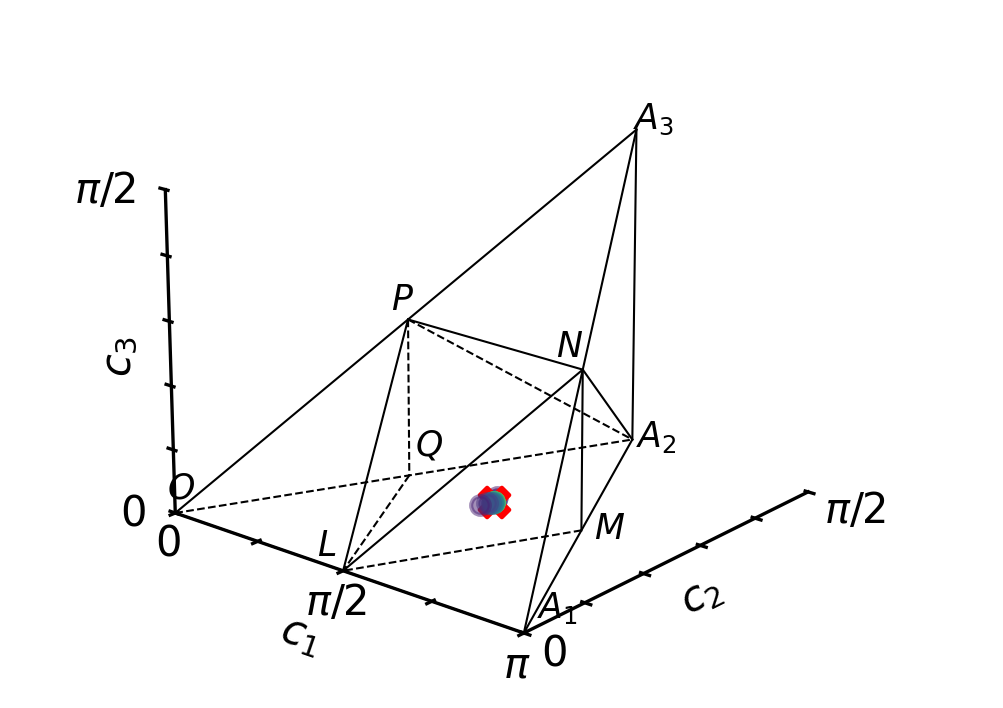

In [7]:
w = WeylChamber()

for idx in range(len(coordinate_iteration_list)):
    color = NaiveCost.to_color(idx, max_cost=len(coordinate_iteration_list))
    w.scatter(*coordinate_iteration_list[idx], color=color, alpha=0.5)
    # print(coordinate_iteration_list[idx])
w.scatter(*target_coords, marker="X", color="red", s=50)
w.plot()

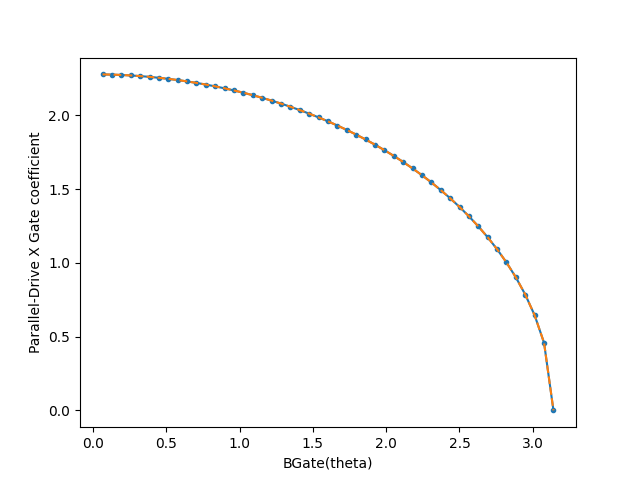

In [4]:
theta_list = np.linspace(0, np.pi, 50)[1:]
pd_ix_angle = []
for b_theta in theta_list:
    target_gate = BGate(b_theta).to_matrix()
    fixed_zz = 3 * b_theta / 2
    result = minimize(
        b_gate_objective, x0, method="Nelder-Mead", callback=save_progress
    )
    assert result.success
    pd_ix_angle.append(result.x[0])

magic_val = 5.19393248
fit = lambda x: np.sqrt((magic_val - magic_val * x**2 / np.pi**2))

# plot pd_ix_angle vs theta_list
import matplotlib.pyplot as plt

plt.close("all")
plt.plot(theta_list, pd_ix_angle, marker=".")
plt.plot(theta_list, fit(theta_list), "--")
plt.xlabel("BGate(theta)")
plt.ylabel("Parallel-Drive X Gate coefficient")
plt.show()


# fit this to a curve
# from scipy.optimize import curve_fit
# f = lambda x, a, b: np.sqrt(np.abs((b - b * x**2 / a)))
# params, _ = curve_fit(f, theta_list, pd_ix_angle, p0=[np.pi**2, 5.0625])
# params = [np.pi**2, 5.19393248], not sure if that second one has a nicer form

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 0.0
             x: [-8.876e-05 -7.448e-05 -3.042e+00  3.042e+00]
           nit: 156
          nfev: 267
 final_simplex: (array([[-8.876e-05, -7.448e-05, -3.042e+00,  3.042e+00],
                       [-8.702e-05, -1.098e-05, -3.042e+00,  3.042e+00],
                       ...,
                       [-1.046e-04, -6.718e-05, -3.042e+00,  3.042e+00],
                       [-1.318e-04,  5.131e-06, -3.042e+00,  3.042e+00]]), array([ 0.000e+00,  0.000e+00,  0.000e+00,  0.000e+00,
                        0.000e+00]))

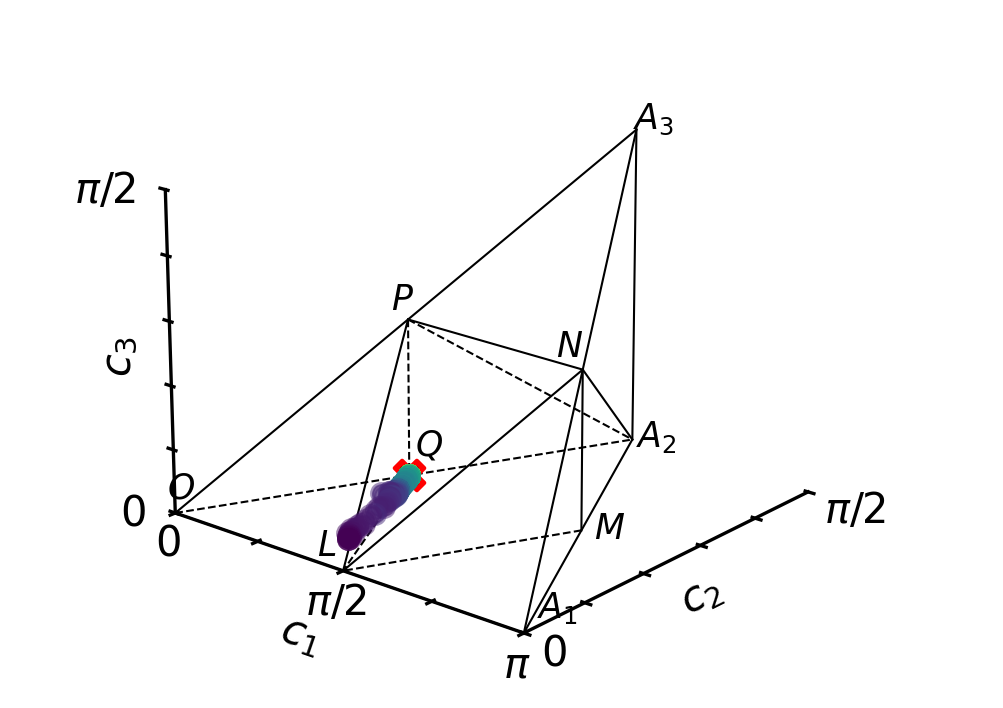

In [6]:
# similarly, find iSWAP.power(1/2)
# except now we have two free parameters, for ZZ() and X()

target_gate = iSwapGate().power(1 / 2).to_matrix()
# target_gate = BGate().to_matrix()

target_coords = list(c1c2c3(target_gate))
if target_coords[0] > 0.5:
    target_coords[0] = 1 - target_coords[0]


def iswap_gate_objective(x0):
    U = ZZ_ParallelDrive(np.pi / 2, x0[0], x0[1], x0[2], x0[3]).to_unitary()
    c1, c2, c3 = c1c2c3(U)
    if c1 > 0.5:
        c1 = 1 - c1
    coordinate_iteration_list.append((c1, c2, c3))
    return J_T_LI(U.to_matrix(), target_gate)


x0 = (3.04211577, -3.04211577, -1, +2)  # only need a single parameter !?
coordinate_iteration_list = []
result = minimize(
    iswap_gate_objective, x0, method="Nelder-Mead", callback=save_progress
)

w = WeylChamber()

for idx in range(len(coordinate_iteration_list)):
    color = NaiveCost.to_color(idx, max_cost=len(coordinate_iteration_list))
    w.scatter(*coordinate_iteration_list[idx], color=color, alpha=0.5)
    # print(coordinate_iteration_list[idx])
w.scatter(*target_coords, marker="X", color="red", s=50)
w.plot()

result

In [ ]:
result.x

array([2.35576438, 1.97413943])

In [ ]:
# w = WeylChamber()
# for theta in np.linspace(0, np.pi, 20):
#     u = BGate(theta)
#     target_coords = list(c1c2c3(u))
#     if target_coords[0] > 0.5:
#         target_coords[0] = 1 - target_coords[0]
#     w.scatter(*target_coords)
# w.plot()